# Import Libraries

In [5]:
import pandas as pd
from pathlib import Path
from keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt
import seaborn as sns


# Configuring project paths and importing core modules

## 

In [6]:
def find_repo_root(start):
    for candidate in [start] + list(start.parents):
        if (candidate / "README.md").exists() or (candidate / "src").exists() or (candidate / ".git").exists():
            return candidate
    return start

BASE_DIR = find_repo_root(Path.cwd())
DATA_DIR = BASE_DIR / "data"
FEATURES_DIR = DATA_DIR / "dl_features"
RESULTS_DIR = BASE_DIR / "results"
MODELS_DIR = RESULTS_DIR / "models"
MODELS_DIR.mkdir(parents=True, exist_ok=True)

print(BASE_DIR)
print(DATA_DIR)
print(FEATURES_DIR)
print(MODELS_DIR)

c:\Life\FCAI\Specialization - AI\Third_Year\2nd Semester\3 - Supervised Learning\7- Projects\nlp-fake-news-detector-transformers
c:\Life\FCAI\Specialization - AI\Third_Year\2nd Semester\3 - Supervised Learning\7- Projects\nlp-fake-news-detector-transformers\data
c:\Life\FCAI\Specialization - AI\Third_Year\2nd Semester\3 - Supervised Learning\7- Projects\nlp-fake-news-detector-transformers\data\dl_features
c:\Life\FCAI\Specialization - AI\Third_Year\2nd Semester\3 - Supervised Learning\7- Projects\nlp-fake-news-detector-transformers\results\models


In [7]:
%load_ext autoreload
%autoreload 2

import sys
import pickle
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

sys.path.append(str(BASE_DIR))

from src.models.deep_learning import CNN

def load_features():
    X_train_pad = np.load(FEATURES_DIR / "X_train_pad.npy")
    X_val_pad = np.load(FEATURES_DIR / "X_val_pad.npy")
    X_test_pad = np.load(FEATURES_DIR / "X_test_pad.npy")

    y_train = np.load(FEATURES_DIR / "y_train.npy")
    y_val = np.load(FEATURES_DIR / "y_val.npy")
    y_test = np.load(FEATURES_DIR / "y_test.npy")

    with open(FEATURES_DIR / "meta.pkl", "rb") as f:
        meta = pickle.load(f)

    return X_train_pad, X_val_pad, X_test_pad, y_train, y_val, y_test, meta

def build_cnn_model(max_words, max_len, dropout_rate=0.5, optimizer="adam"):
    cnn = CNN(
        vocab_size=max_words,
        max_length=max_len,
        dropout_rate=dropout_rate,
    )
    cnn.build()
    cnn.compile(optimizer=optimizer)
    return cnn.model

def evaluate_model(model, X_test, y_test):
    y_pred_probs = model.predict(X_test, verbose=0).ravel()
    y_pred = (y_pred_probs > 0.5).astype(int)

    metrics = {
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred, zero_division=0),
        "f1": f1_score(y_test, y_pred, zero_division=0),
    }

    print("\nEvaluation Results:")
    for name, value in metrics.items():
        print(f"{name.title()}: {value:.4f}")

    return metrics

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Hyperparameter Tuning & Experiments
To achieve the best performance, we conduct several experiments varying the following:
* **Optimizers:** Adam vs. RMSprop.
* **Dropout Rates:** 0.5 vs. 0.7 (to control overfitting).
* **Batch Sizes:** 32 vs. 64.

We use **Early Stopping** to prevent overfitting and ensure the model stops training once the validation loss stabilizes.

In [8]:
X_train, X_val, X_test, y_train, y_val, y_test, meta = load_features()

experiments = [
    {"name": "Baseline (Adam, 0.5 DP, 32 BS)", "opt": "adam", "dr": 0.5, "bs": 32},
    {"name": "High Dropout(Adam) (Adam, 0.7 DP, 32 BS)", "opt": "adam", "dr": 0.7, "bs": 32},
    {"name": "Large Batch(Adam) (Adam, 0.5 DP, 64 BS)", "opt": "adam", "dr": 0.5, "bs": 64},

    {"name": "RMSprop (RMS, 0.5 DP, 32 BS)", "opt": "rmsprop", "dr": 0.5, "bs": 32},
    {"name": "High Dropout(RMSprop) (RMS, 0.7 DP, 32 BS)", "opt": "rmsprop", "dr": 0.7, "bs": 32},
    {"name": "Large Batch(RMSprop) (RMS, 0.5 DP, 64 BS)", "opt": "rmsprop", "dr": 0.5, "bs": 64},
]

results_list = [] 

In [9]:
early_stopping = EarlyStopping(monitor = 'val_loss',
                               patience = 2,
                               restore_best_weights = True)

In [10]:
def run_experiment(exp, X_train, y_train, X_val, y_val, X_test, y_test, meta):
    model = build_cnn_model(
        max_words=meta["max_words"],
        max_len=meta["max_len"],
        dropout_rate=exp["dr"],
        optimizer=exp["opt"]
    )

    model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=10,
        batch_size=exp["bs"],
        callbacks=[early_stopping],
        verbose=0
    )

    metrics = evaluate_model(model, X_test, y_test)

    exp_results = exp.copy()
    exp_results.update(metrics)

    return exp_results

results_list = []

for exp in experiments:
    print(f"Running: {exp['name']}")

    result = run_experiment(
        exp,
        X_train, y_train,
        X_val, y_val,
        X_test, y_test,
        meta
    )

    results_list.append(result)

Running: Baseline (Adam, 0.5 DP, 32 BS)


C:\Users\Lenovo\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(



Evaluation Results:
Accuracy: 0.7968
Precision: 0.8103
Recall: 0.7690
F1: 0.7891
Running: High Dropout(Adam) (Adam, 0.7 DP, 32 BS)


C:\Users\Lenovo\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(



Evaluation Results:
Accuracy: 0.7924
Precision: 0.8100
Recall: 0.7578
F1: 0.7830
Running: Large Batch(Adam) (Adam, 0.5 DP, 64 BS)


...


Evaluation Results:
Accuracy: 0.7841
Precision: 0.8049
Recall: 0.7434
F1: 0.7730
Running: High Dropout(RMSprop) (RMS, 0.7 DP, 32 BS)


C:\Users\Lenovo\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(



Evaluation Results:
Accuracy: 0.7818
Precision: 0.7635
Recall: 0.8091
F1: 0.7857
Running: Large Batch(RMSprop) (RMS, 0.5 DP, 64 BS)


C:\Users\Lenovo\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(



Evaluation Results:
Accuracy: 0.7925
Precision: 0.7854
Recall: 0.7984
F1: 0.7918


# Results & Ranking
After running all experiments, we compile the results into a table to compare performance based on **Accuracy, Precision, Recall, and F1-Score**. The experiments are ranked by their **F1-Score**.

In [11]:
results_df = pd.DataFrame(results_list)

results_df = results_df.sort_values(by='f1', ascending=False)

print("\nFinal Experiments Ranking:")
display(results_df)




Final Experiments Ranking:


,name,opt,dr,bs,accuracy,precision,recall,f1
2,"Large Batch(Adam) (Adam, 0.5 DP, 64 BS)",adam,0.5,64,0.794746,0.783132,0.808614,0.795669
5,"Large Batch(RMSprop) (RMS, 0.5 DP, 64 BS)",rmsprop,0.5,64,0.792513,0.785355,0.798375,0.791812
0,"Baseline (Adam, 0.5 DP, 32 BS)",adam,0.5,32,0.796834,0.810265,0.768984,0.789085
4,"High Dropout(RMSprop) (RMS, 0.7 DP, 32 BS)",rmsprop,0.7,32,0.781809,0.763508,0.809140,0.785662
1,"High Dropout(Adam) (Adam, 0.7 DP, 32 BS)",adam,0.7,32,0.792442,0.810006,0.757769,0.783017
3,"RMSprop (RMS, 0.5 DP, 32 BS)",rmsprop,0.5,32,0.784147,0.804913,0.743429,0.772950


# Visualizing Performance
A graphical comparison of the F1-Score across all experiments to clearly identify the top-performing configuration.

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_452\382017120.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='f1', y='name', data=results_df, palette='magma')


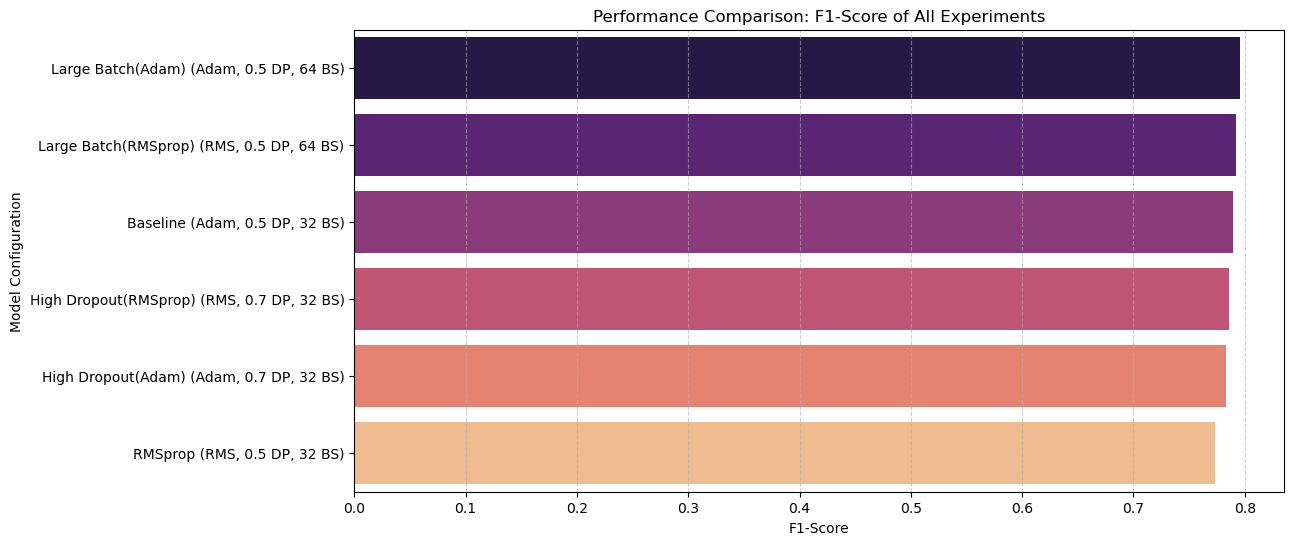

In [12]:
plt.figure(figsize=(12, 6))
sns.barplot(x='f1', y='name', data=results_df, palette='magma')
plt.title('Performance Comparison: F1-Score of All Experiments')
plt.xlabel('F1-Score')
plt.ylabel('Model Configuration')
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.show()

# Final Conclusion & Best Model
Based on the experiments above:
1.  **Best Performer:** The Large Batch(Adam) model achieved the highest F1-Score.
2.  **Optimizer:** {Adam} showed better convergence stability.
3.  **Next Steps:** The final model weights are saved in `results/models/best_cnn_model` for deployment and integration 